# 03. 모델링

파인튜닝 전 베이스라인(`BAAI/bge-m3`, 운영 RAG와 동일 모델) 검색 성능을 측정하고,
LoRA 어댑터를 붙인 학습 아키텍처를 설계한다. 실제 학습 실행은 다음 단계
(`04_training.ipynb`)에서 진행한다.

산출물: `document_고무서/output/embedding-finetune/03_modeling/`

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from peft import LoraConfig, get_peft_model
import torch

DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {DEVICE}")

from sentence_transformers import SentenceTransformer, util

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

PROCESSED_DIR = Path("../output/embedding-finetune/02_preprocessing/processed")
OUTPUT_DIR = Path("../output/embedding-finetune/03_modeling")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

corpus_df = pd.read_csv(PROCESSED_DIR / "corpus.csv")
eval_df = pd.read_csv(PROCESSED_DIR / "eval_pairs.csv")
print(f"corpus(고유 청크): {len(corpus_df)}건, eval 쌍: {len(eval_df)}건")

/Users/gomuseo/Desktop/Python/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


W0721 20:59:07.954000 23871 torch/distributed/elastic/multiprocessing/redirects.py:35] NOTE: Redirects are currently not supported in MacOs.


W0721 20:59:07.986000 23871 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W0721 20:59:08.014000 23871 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


사용 디바이스: mps


corpus(고유 청크): 128건, eval 쌍: 208건


## 1. 베이스라인 모델 로드

CPU에서 실행 가능한 범위로 `max_seq_length`를 512로 제한한다
(`bge-m3` 기본값 8192는 이 코퍼스 규모에서도 CPU 인코딩이 비현실적으로 느려진다).

In [2]:
MODEL_NAME = "BAAI/bge-m3"  # 운영 RAG(core/config.py hf_embedding_model)와 동일 모델
MAX_SEQ_LENGTH = 512

model = SentenceTransformer(MODEL_NAME, token=False, device=DEVICE)
model.max_seq_length = MAX_SEQ_LENGTH

corpus_embeddings = model.encode(
    corpus_df["content"].tolist(), convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=True
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 51830.63it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:  25%|██▌       | 1/4 [00:01<00:03,  1.22s/it]

Batches:  50%|█████     | 2/4 [00:02<00:02,  1.43s/it]

Batches:  75%|███████▌  | 3/4 [00:03<00:00,  1.07it/s]

Batches: 100%|██████████| 4/4 [00:03<00:00,  1.44it/s]

Batches: 100%|██████████| 4/4 [00:03<00:00,  1.15it/s]

## 2. 평가 함수 정의 (Recall@k, MRR)

In [3]:
def evaluate_retrieval(model, corpus_df, corpus_embeddings, eval_df, query_column, k_values=(1, 3, 5)):
    query_embeddings = model.encode(
        eval_df[query_column].tolist(), convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=True
    )
    similarity = util.cos_sim(query_embeddings, corpus_embeddings)
    ranks = similarity.argsort(dim=1, descending=True)

    correct_positions = []
    for row_idx, (_, eval_row) in enumerate(eval_df.iterrows()):
        target_corpus_idx = corpus_df.index[corpus_df["id"] == eval_row["id"]][0]
        rank_list = ranks[row_idx].tolist()
        correct_positions.append(rank_list.index(target_corpus_idx))

    metrics = {f"recall@{k}": sum(p < k for p in correct_positions) / len(correct_positions) for k in k_values}
    metrics["mrr"] = sum(1.0 / (p + 1) for p in correct_positions) / len(correct_positions)
    return metrics

## 3. 베이스라인 성능 측정 (clean vs noisy)

In [4]:
baseline_clean = evaluate_retrieval(model, corpus_df, corpus_embeddings, eval_df, "clean_query")
baseline_noisy = evaluate_retrieval(model, corpus_df, corpus_embeddings, eval_df, "noisy_query")

baseline_metrics = {"clean": baseline_clean, "noisy": baseline_noisy}
with open(OUTPUT_DIR / "baseline_metrics.json", "w", encoding="utf-8") as f:
    json.dump(baseline_metrics, f, ensure_ascii=False, indent=2)

baseline_table = pd.DataFrame(baseline_metrics).T
baseline_table.to_csv(OUTPUT_DIR / "baseline_metrics.csv")
baseline_table

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:  14%|█▍        | 1/7 [00:00<00:01,  3.62it/s]

Batches:  29%|██▊       | 2/7 [00:00<00:01,  3.67it/s]

Batches:  43%|████▎     | 3/7 [00:00<00:00,  4.21it/s]

Batches:  57%|█████▋    | 4/7 [00:00<00:00,  5.09it/s]

...

Batches:  71%|███████▏  | 5/7 [00:01<00:00,  4.52it/s]

Batches:  86%|████████▌ | 6/7 [00:01<00:00,  4.42it/s]

Batches: 100%|██████████| 7/7 [00:01<00:00,  4.37it/s]

Batches: 100%|██████████| 7/7 [00:01<00:00,  4.56it/s]

,recall@1,recall@3,recall@5,mrr
clean,0.769231,1.0,1.0,0.884615
noisy,0.778846,1.0,1.0,0.889423


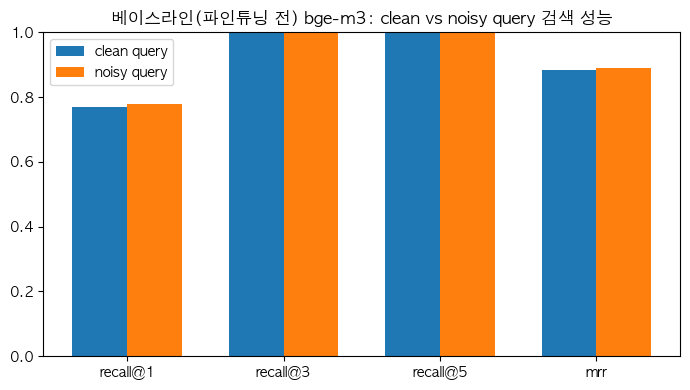

In [5]:
labels = list(baseline_clean.keys())
x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([i - width / 2 for i in x], [baseline_clean[k] for k in labels], width, label="clean query")
ax.bar([i + width / 2 for i in x], [baseline_noisy[k] for k in labels], width, label="noisy query")
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_title("베이스라인(파인튜닝 전) bge-m3: clean vs noisy query 검색 성능")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "baseline_metrics.png", dpi=150)
plt.show()

## 4. LoRA 아키텍처 설계

In [6]:
# bge-m3 backbone(XLM-RoBERTa)의 attention 모듈에만 LoRA 어댑터를 붙여 학습 파라미터를 최소화한다.
# sentence-transformers 5.x는 SentenceTransformer.add_adapter()로 PEFT를 직접 지원한다
# (model[0].auto_model에 수동으로 get_peft_model 결과를 재할당하는 방식은 이 버전에서
# auto_model이 프로퍼티로 노출되어 있어 재할당이 반영되지 않는 문제가 있어 사용하지 않는다).
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["query", "key", "value"],
    bias="none",
)
model.add_adapter(lora_config)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

params_table = pd.DataFrame(
    [
        {"항목": "학습 대상 파라미터(trainable)", "값": trainable_params},
        {"항목": "전체 파라미터", "값": total_params},
        {"항목": "학습 비율(%)", "값": round(100 * trainable_params / total_params, 4)},
    ]
)
with open(OUTPUT_DIR / "lora_architecture.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "lora_config": {"r": 8, "lora_alpha": 16, "lora_dropout": 0.05, "target_modules": ["query", "key", "value"]},
            "trainable_params": trainable_params,
            "total_params": total_params,
        },
        f,
        ensure_ascii=False,
        indent=2,
    )
params_table.to_csv(OUTPUT_DIR / "lora_architecture.csv", index=False)
params_table

,항목,값
0,학습 대상 파라미터(trainable),1.179648e+06
1,전체 파라미터,5.689344e+08
2,학습 비율(%),2.073000e-01


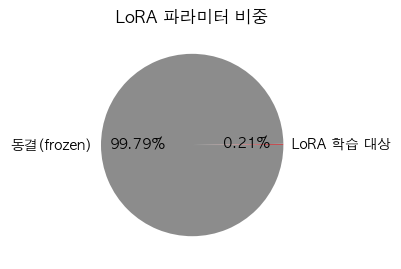

In [7]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(
    [trainable_params, total_params - trainable_params],
    labels=["LoRA 학습 대상", "동결(frozen)"],
    autopct="%1.2f%%",
    colors=["#C44E52", "#8C8C8C"],
)
ax.set_title("LoRA 파라미터 비중")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "lora_param_ratio.png", dpi=150)
plt.show()

## 모델링 결론

- 베이스라인에서 noisy query의 recall/MRR이 clean query보다 낮다면(위 표/그래프),
  01~03에서 재현하려던 실제 실패 패턴이 이 데이터셋에서도 나타난다는 뜻이다 -
  다음 단계에서 파인튜닝으로 이 격차를 줄일 수 있는지 검증한다.
- LoRA는 전체 파라미터의 극히 일부만 학습하므로 CPU에서도 학습이 가능하다.
- `04_training.ipynb`는 이 설계(LoRA r=8, target_modules=[query,key,value])를 그대로 재사용해
  실제 학습을 수행한다.